# Paper trained-masking ablations
Load the five depth-2 GIN checkpoints trained with 2% identity masking. First reproduce total recipient/source heatmaps with legacy pair-coverage sampling and source non-overlap. Then sample centers uniformly across validation cells and add targeted centers until each source lineage at hops 0, 1 and 2 has at least 50 eligible cases per fold where available. Mask one cell at a time; preserve graph structure and global features. Unassigned is an observed identity distinct from unknown/masked fate.

Report edited minus intact curvature, squared error and absolute error in physical units. Pair heatmaps average within organoids then across organoids. Source-distance curves instead weight sampled recipients equally to reflect cell abundance; top-ups change that distribution, so show random-only estimates alongside the requested combined sample. These are conditional model responses, not biological interventions. All inference is checkpointed and memory-bounded; no training occurs here.

In [1]:
from pathlib import Path
import sys
import json
import hashlib
import gc
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from functools import lru_cache
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/models/gnn.py').is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0,str(PROJECT_ROOT))
from src.artifacts.runs import AnalysisRun
from src.artifacts.provenance import workflow_fingerprint
from src.analysis.metrics.evaluation import prediction_table, organoid_mse_summary
from src.analysis.spatial.regions import signed_neck_regions
from src.analysis.interventions.fate_edits import fate_graphs, sample_fate_contexts, sample_random_topup_contexts, evaluate_fate_edit, summarize_fate_effects, count_fate_cases
from src.plotting.influence_maps import plot_pair_count_heatmaps, plot_pair_heatmaps


## Settings
Configure saved models, the two distinct sampling designs and figure support thresholds.

In [2]:
# Study and inference
STUDY_DIR = PROJECT_ROOT/'paper_results/exclusive_lineages/paper_exclusive_20261006_153255'  # Dedicated paper output.
MANIFEST = json.loads((STUDY_DIR/'manifest.json').read_text())  # Exact saved runs.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # Inference device.
BATCH_SIZE = 64  # Maximum graphs per inference batch.
RECOMPUTE = False  # Reuse caches from identical code/settings.

# Reporting and anatomical definitions
CURVATURE_SCALE = 1e-4  # Gaussian curvature and MAE to um^-2; MSE uses square.
CRYPT_MAX = .75  # Legacy normalized crypt-distance threshold.
NECK_MAX = 1.1  # Legacy neck upper boundary, inclusive.
FIGURE_FORMATS = ['png','pdf']  # Figure exports.

# Trained masking intervention
MODEL_DEPTH = 2  # Exact saved depth; evaluate all saved folds.
MASKING_RATE = .02  # Only checkpoints trained with two-percent missing-fate masks.
SAMPLING_SEED = 0  # Fold index added for reproducible selection.

# Pair-coverage sampling: historical total-ablation design
CENTER_SAMPLE_SIZE = 2000  # Maximum centers per validation fold.
CENTER_MIN_MARKER_COUNT = 50  # Requested minimum recipient centers per lineage.
CENTER_MIN_PAIR_COUNT = 25  # Requested minimum per recipient/source/hop before non-overlap.
APPLY_NON_OVERLAP = True  # Remove sources within hop distance within each pair/hop stratum.
HEATMAP_MIN_CASES = 20  # Hatch effects below this retained support.

# Population-style source curves: random centers then targeted top-up
RANDOM_CENTERS = 2000  # Uniform initial sample from all validation cells in each fold.
MIN_SOURCE_HOP_CASES = 50  # Top up each source/hop, or report all available if rarer.
SOURCE_HOPS = [0,1,2]  # Include masking the center itself at hop zero.

# Uncertainty
BOOTSTRAP_REPEATS = 500  # Resample whole organoids, conditional on fitted models.


## Restore saved models
Select the positive-rate checkpoints and isolate caches by executable code and settings.

In [3]:
def save_figure(fig, path):
    path.parent.mkdir(parents=True,exist_ok=True)
    for extension in FIGURE_FORMATS:
        fig.savefig(path.with_suffix('.'+extension),dpi=180,bbox_inches='tight')
    plt.show()
    plt.close(fig)

METRIC_LABELS = {'mse':r'MSE ($\mu$m$^{-4}$)', 'mae':r'MAE ($\mu$m$^{-2}$)'}
run=AnalysisRun(MANIFEST['runs']['masking'])
assert (run.directory/'complete.json').exists()
records=run.records[(run.records.depth==MODEL_DEPTH)&np.isclose(run.records.rate,MASKING_RATE)].sort_values('fold')
assert len(records)==5 and records.fold.nunique()==5
OUTPUT_DIR=STUDY_DIR/'masking_ablation';OUTPUT_DIR.mkdir(exist_ok=True)
CACHE=run.directory/'analysis'/'paper_masking'/workflow_fingerprint(PROJECT_ROOT/'experiments/paper/masking_ablation.ipynb')[:12]
CACHE.mkdir(parents=True,exist_ok=True)
print('Five held-out folds; masking identity, never deleting cells or replacing them with Unassigned.')


Five held-out folds; masking identity, never deleting cells or replacing them with Unassigned.


## Coverage sampling and inference
Choose centers before building ego graphs; verify intact ego predictions against full-graph predictions and persist each fold immediately.

In [4]:
def infer_cases(kind):
    parts=[];support_parts=[]
    for record in records.to_dict('records'):
        path=CACHE/f"{kind}_{record['key']}.csv.gz"
        support_path=CACHE/f"support_{kind}_{record['key']}.csv"
        if RECOMPUTE or not path.exists():
            selection=run.select(record['key'],device=DEVICE)
            graphs=fate_graphs(selection);names=selection['marker_names']
            if kind=='pairs':
                subs,cases,info=sample_fate_contexts(graphs,names,MODEL_DEPTH,scheme='coverage',
                    max_subgraphs=CENTER_SAMPLE_SIZE,min_center_count=CENTER_MIN_MARKER_COUNT,
                    min_pair_count=CENTER_MIN_PAIR_COUNT,seed=SAMPLING_SEED+record['fold'],
                    apply_non_overlap=APPLY_NON_OVERLAP,return_info=True)
                support=info['pair_coverage']
                for field in ('center_coverage','case_non_overlap'):
                    info[field].to_csv(CACHE/f"{field}_{record['key']}.csv",index=False)
            else:
                subs,cases,support=sample_random_topup_contexts(graphs,names,MODEL_DEPTH,
                    random_centers=RANDOM_CENTERS,minimum_count=MIN_SOURCE_HOP_CASES,
                    hops=SOURCE_HOPS,seed=SAMPLING_SEED+record['fold'])
            result=evaluate_fate_edit(selection,subs,cases,'masking',device=DEVICE,batch_size=BATCH_SIZE,allow_center=kind=='population')
            full=prediction_table(selection,device=DEVICE,batch_size=BATCH_SIZE).set_index(['organoid_str','node'])
            expected=full.loc[pd.MultiIndex.from_arrays([result.organoid_str,result.orig_center]),'pred_transformed'].to_numpy()
            np.testing.assert_allclose(result.base_z,expected,rtol=2e-4,atol=2e-6)
            result['fold']=record['fold'];result['seed']=record['seed'];result['model_key']=record['key']
            result['center_marker_names']=result.center_marker_names.map(json.dumps)
            result['delta_mu']*=CURVATURE_SCALE
            result['delta_mse']*=CURVATURE_SCALE**2
            result['delta_mae']*=CURVATURE_SCALE
            support.assign(fold=record['fold']).to_csv(support_path,index=False)
            temporary=path.with_suffix('.tmp');result.to_csv(temporary,index=False,compression='gzip');temporary.replace(path)
            print(f"{kind}, fold {record['fold']}: {len(subs)} centers, {len(result)} single-source edits",flush=True)
            del selection,graphs,subs,cases,result,full
            run._data_cache.clear();gc.collect();torch.cuda.empty_cache()
        parts.append(pd.read_csv(path));support_parts.append(pd.read_csv(support_path))
    return pd.concat(parts,ignore_index=True),pd.concat(support_parts,ignore_index=True)

pair_cases,pair_support=infer_cases('pairs')
IDENTITIES=list(pair_support.center_marker.drop_duplicates())


pairs, fold 0: 2000 centers, 9288 single-source edits


pairs, fold 1: 2000 centers, 9299 single-source edits


pairs, fold 2: 2000 centers, 9170 single-source edits


pairs, fold 3: 2000 centers, 9249 single-source edits


pairs, fold 4: 2000 centers, 9200 single-source edits


## Sampling coverage
Counts precede response heatmaps. Coverage quotas apply before the historical non-overlap filter; display thresholds use retained cases.

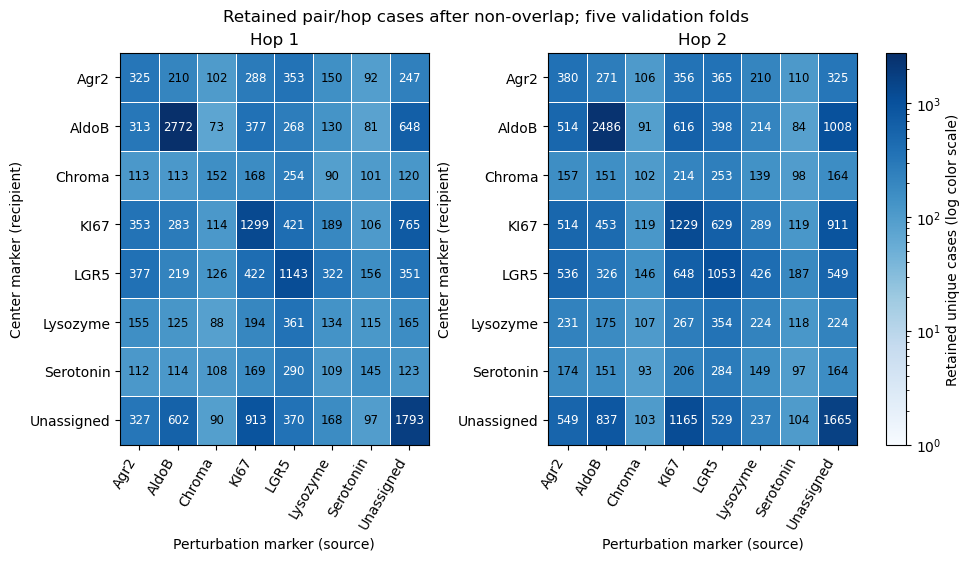

In [5]:
pair_counts=count_fate_cases(pair_cases,metric='delta_mu')
pair_counts.to_csv(OUTPUT_DIR/'pair_sample_counts.csv',index=False)
fig=plot_pair_count_heatmaps(pair_counts,hops=[1,2],marker_names=IDENTITIES,title='Retained pair/hop cases after non-overlap; five validation folds')
save_figure(fig,OUTPUT_DIR/'pair_sample_counts')
pair_support.to_csv(OUTPUT_DIR/'pair_sampling_support.csv',index=False)


## Total pairwise effects
Positive error changes mean masking worsens prediction. Hatching denotes insufficient retained support; no numbers obscure effect cells.

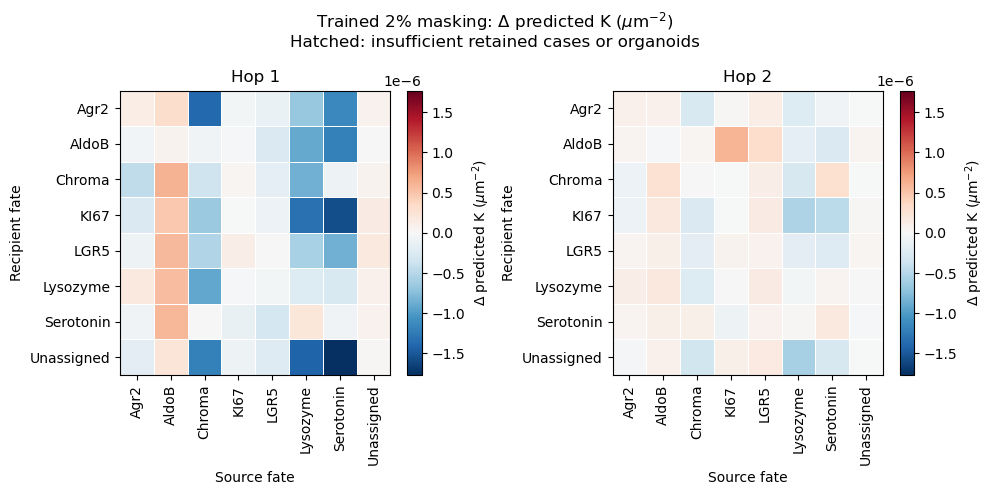

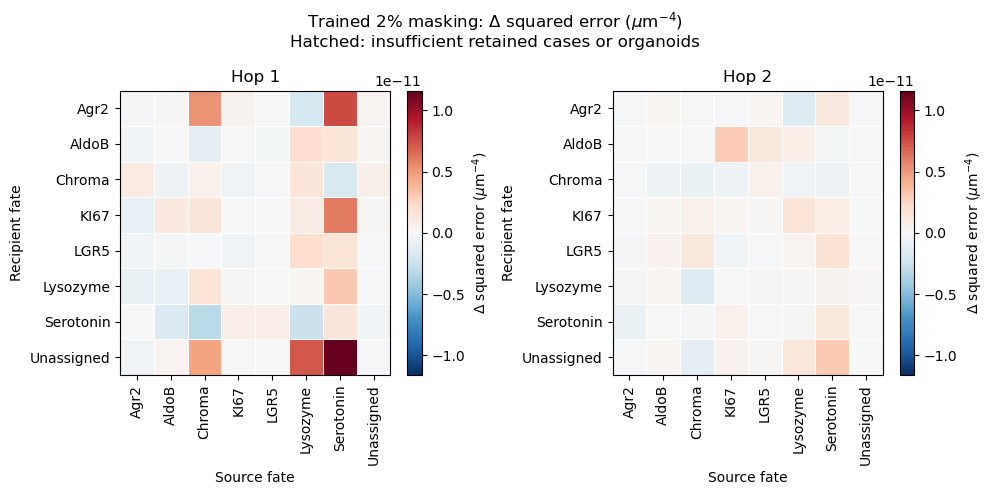

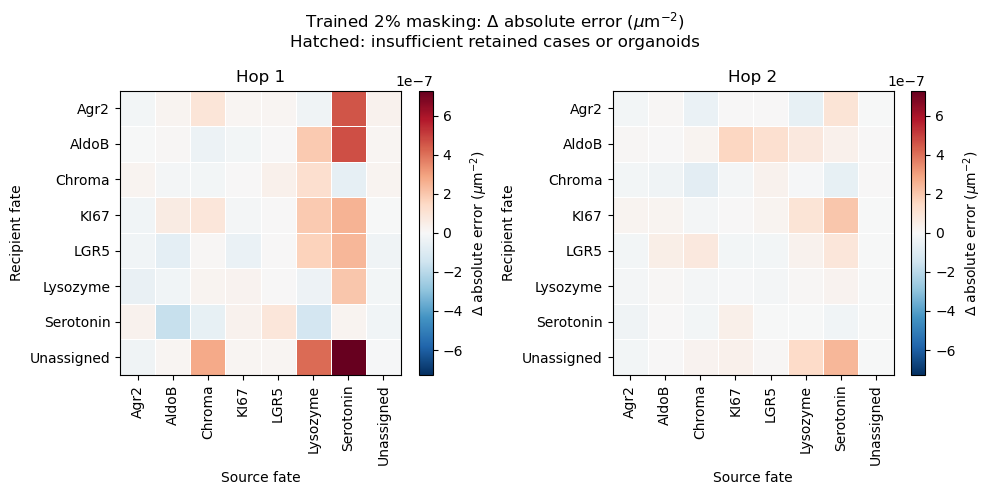

In [6]:
EFFECT_LABELS={'delta_mu':r'Δ predicted K ($\mu$m$^{-2}$)',
    'delta_mse':r'Δ squared error ($\mu$m$^{-4}$)', 'delta_mae':r'Δ absolute error ($\mu$m$^{-2}$)'}
for metric,label in EFFECT_LABELS.items():
    summary=summarize_fate_effects(pair_cases,view='total',metric=metric,draws=BOOTSTRAP_REPEATS,seed=SAMPLING_SEED)
    summary.to_csv(OUTPUT_DIR/f'pair_{metric}.csv',index=False)
    fig=plot_pair_heatmaps(summary,title=f'Trained 2% masking: {label}',min_cases=HEATMAP_MIN_CASES,hops=[1,2],marker_names=IDENTITIES)
    for ax in fig.axes:
        if ax.get_ylabel()=='Edited − intact prediction':ax.set_ylabel(label)
    save_figure(fig,OUTPUT_DIR/f'pair_{metric}')


## Random-center sampling with targeted top-ups
Pool all recipient identities for each source and distance. Hop zero masks the recipient itself and is a larger identity intervention than masking a neighbor.

Blue denotes random-only samples and orange denotes random samples plus targeted top-ups in both sampling and response figures. All lineage panels share y-limits within each response metric; shaded bands show organoid-bootstrap 95% intervals.

Support shortfalls: 0 source/hop/fold strata.


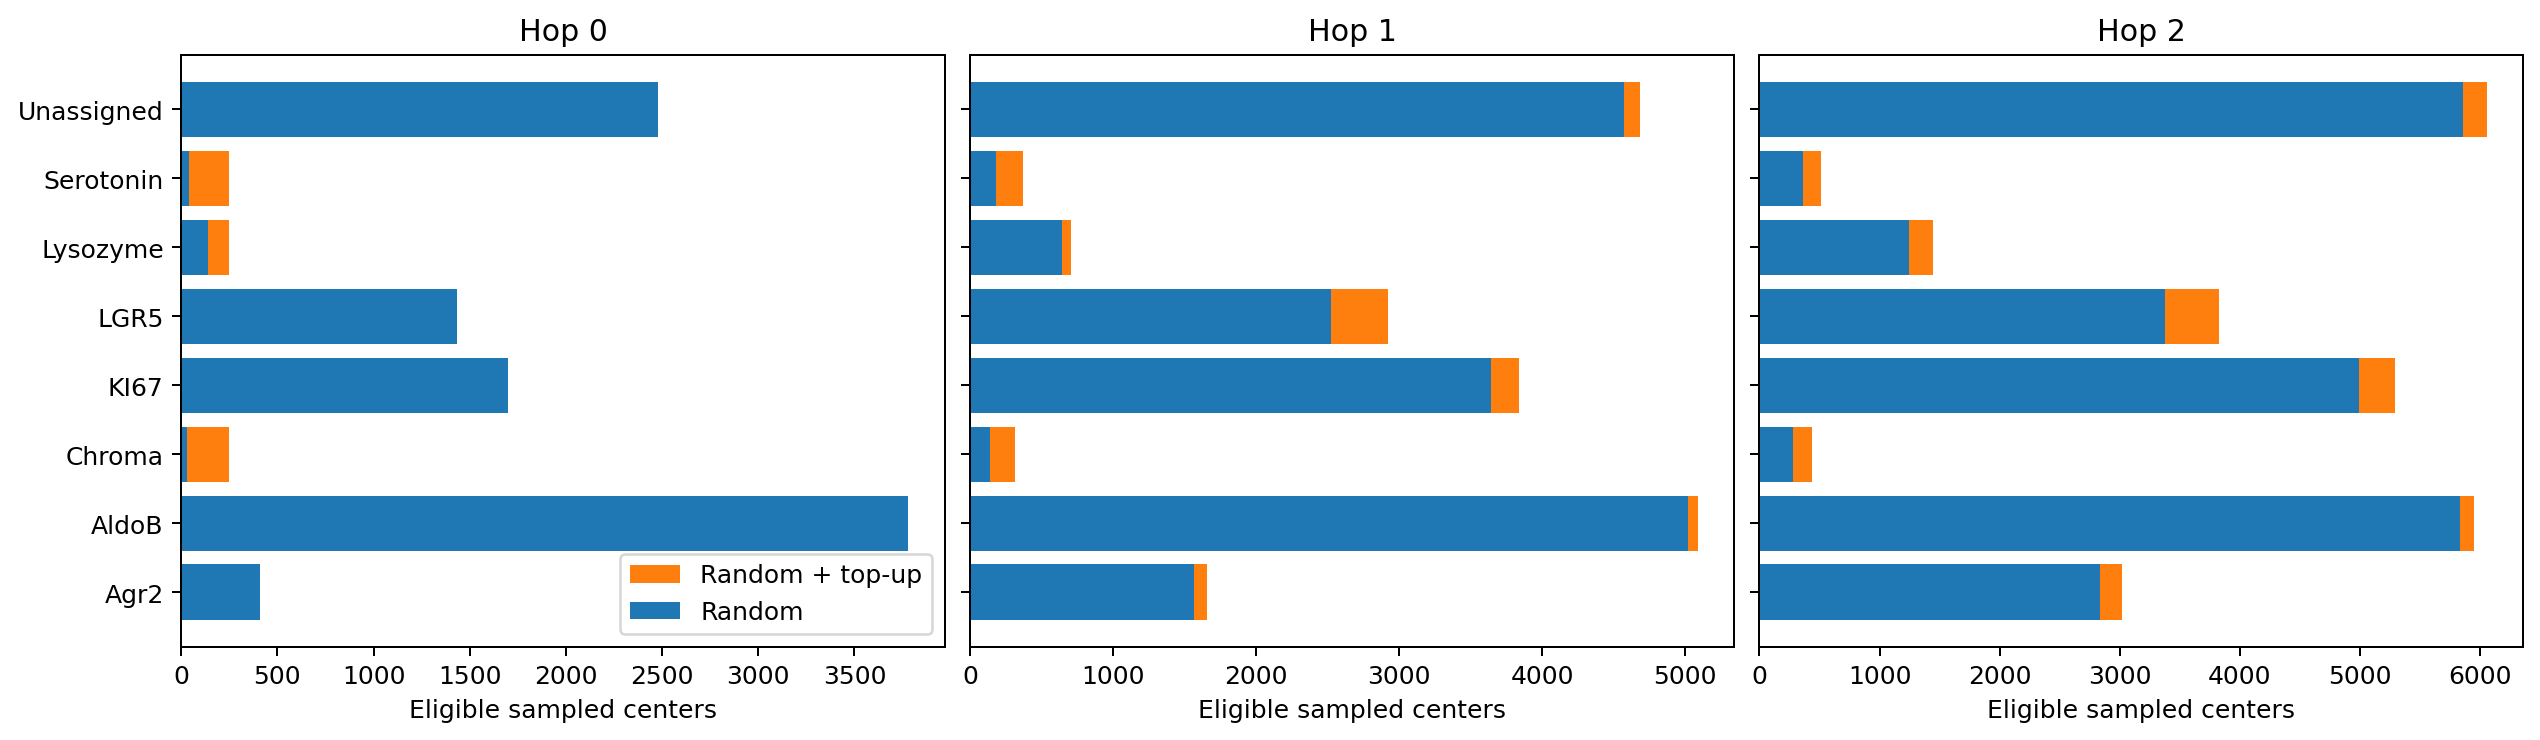

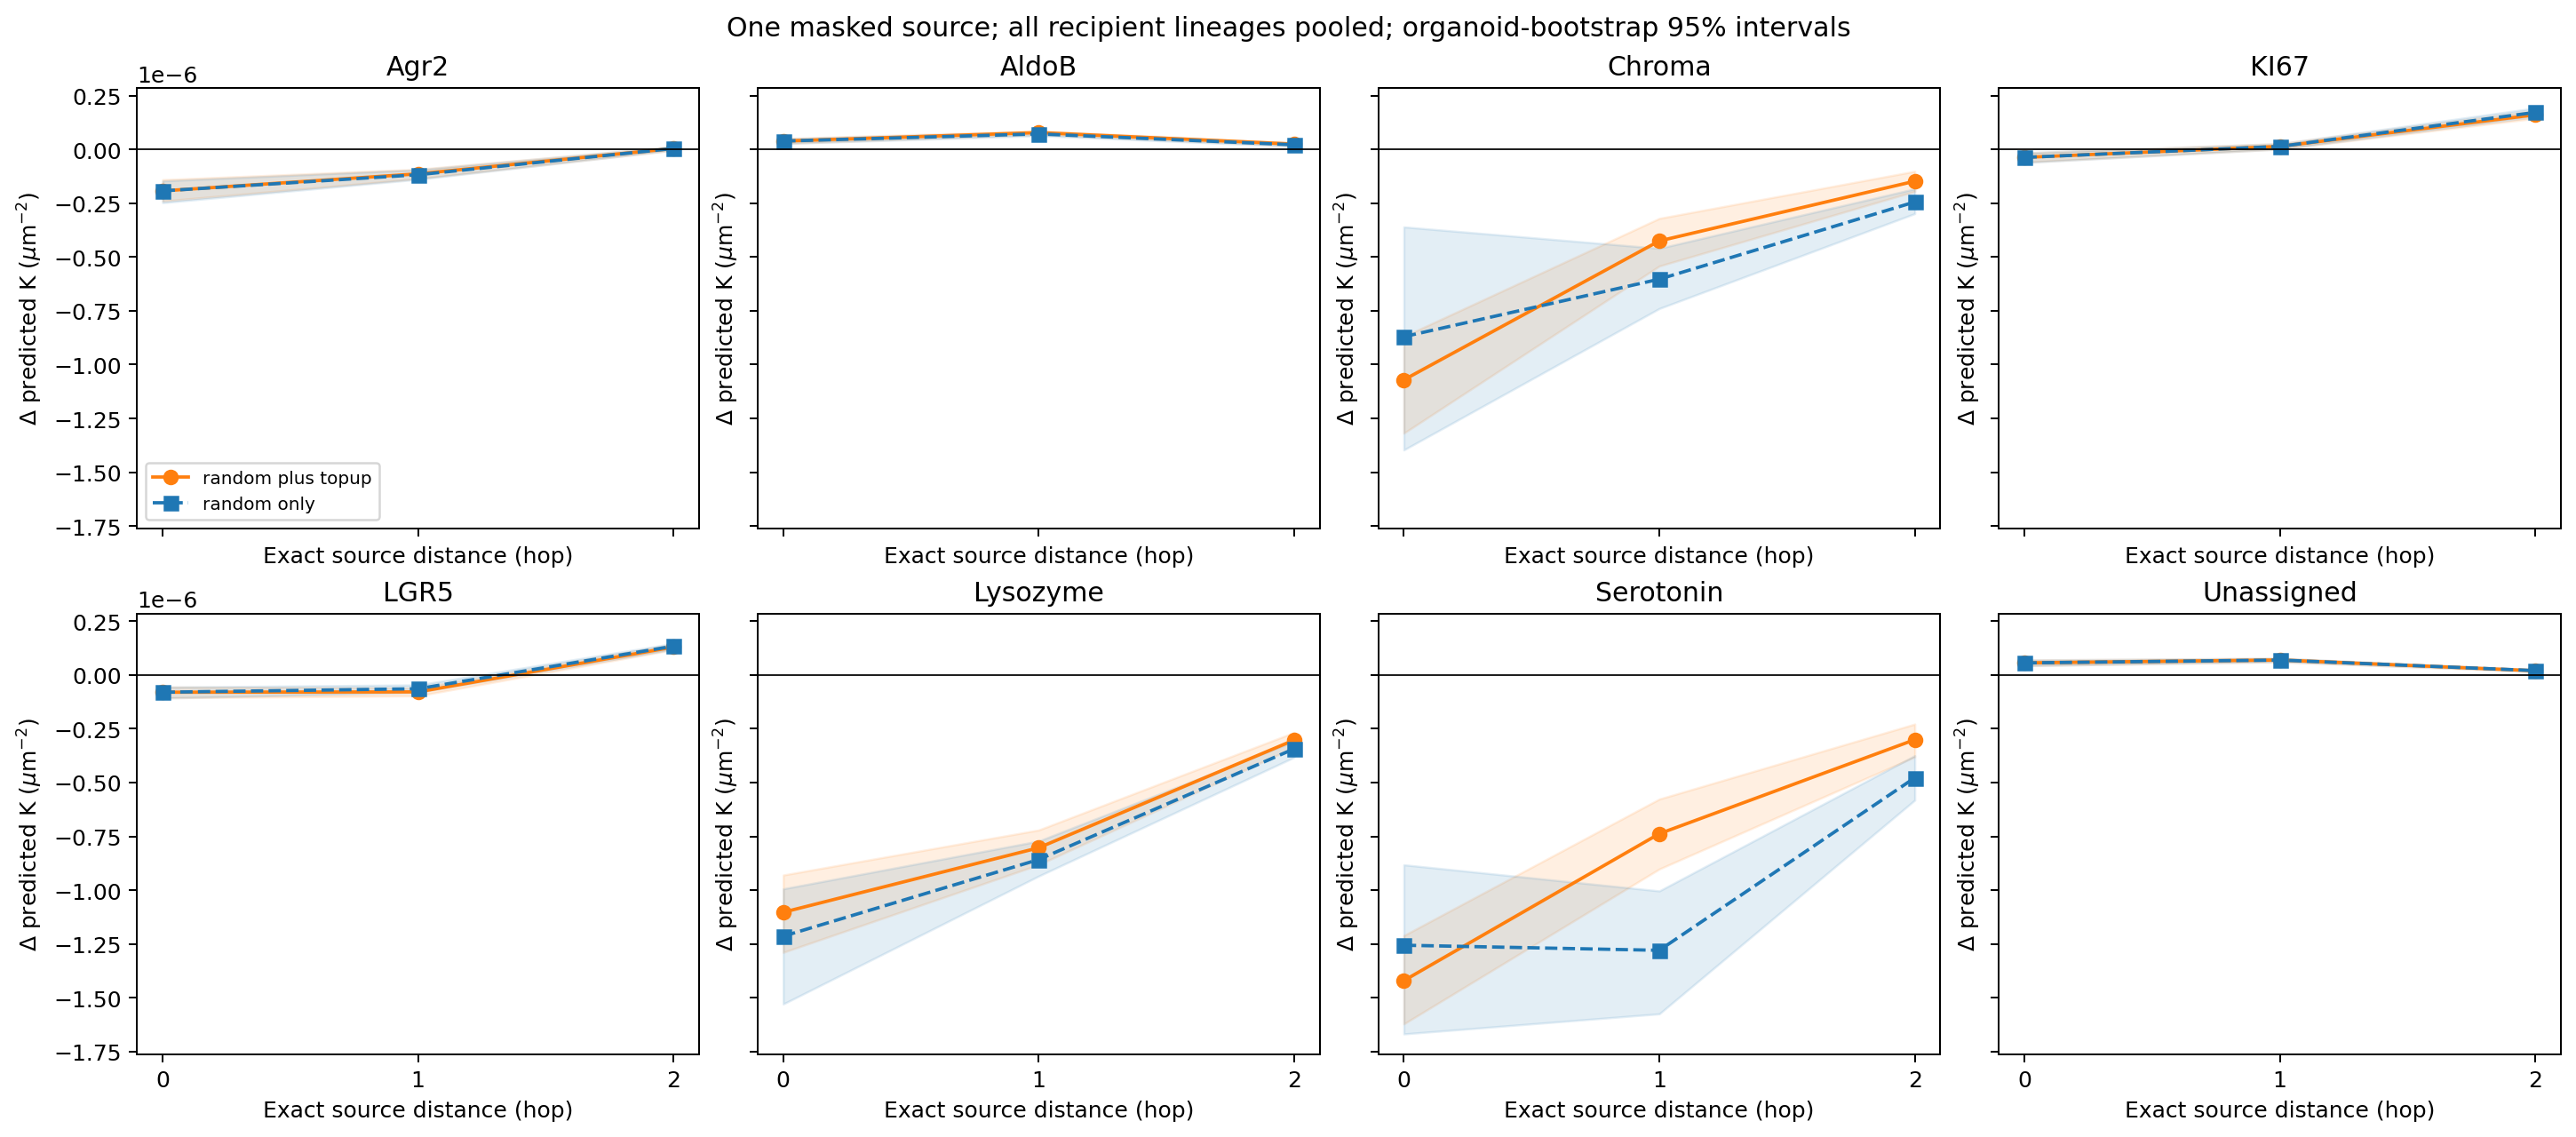

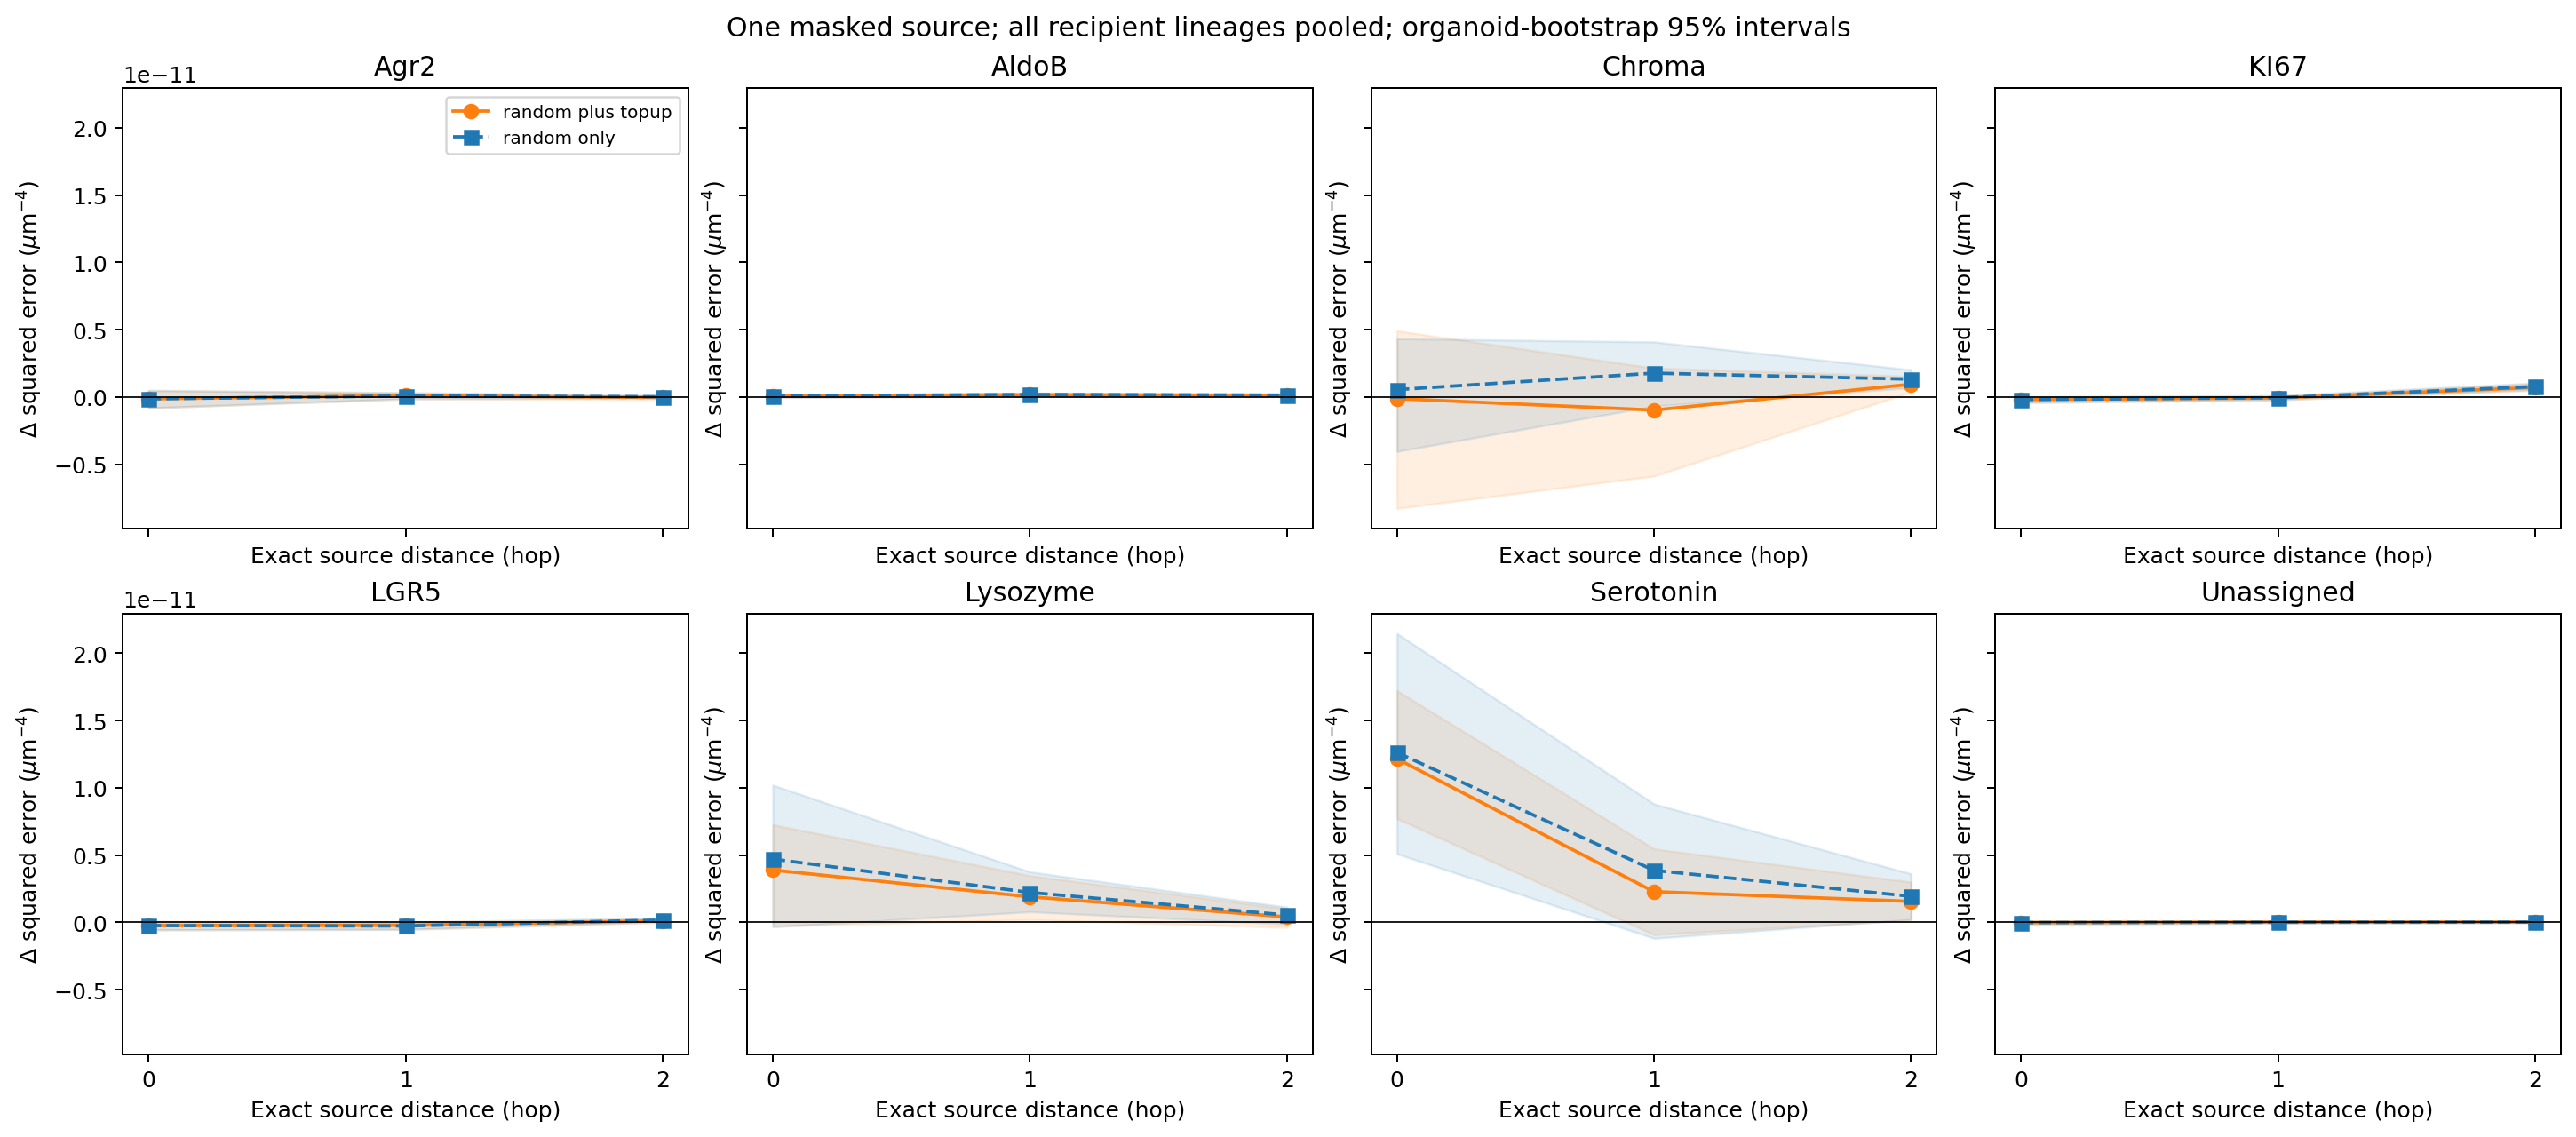

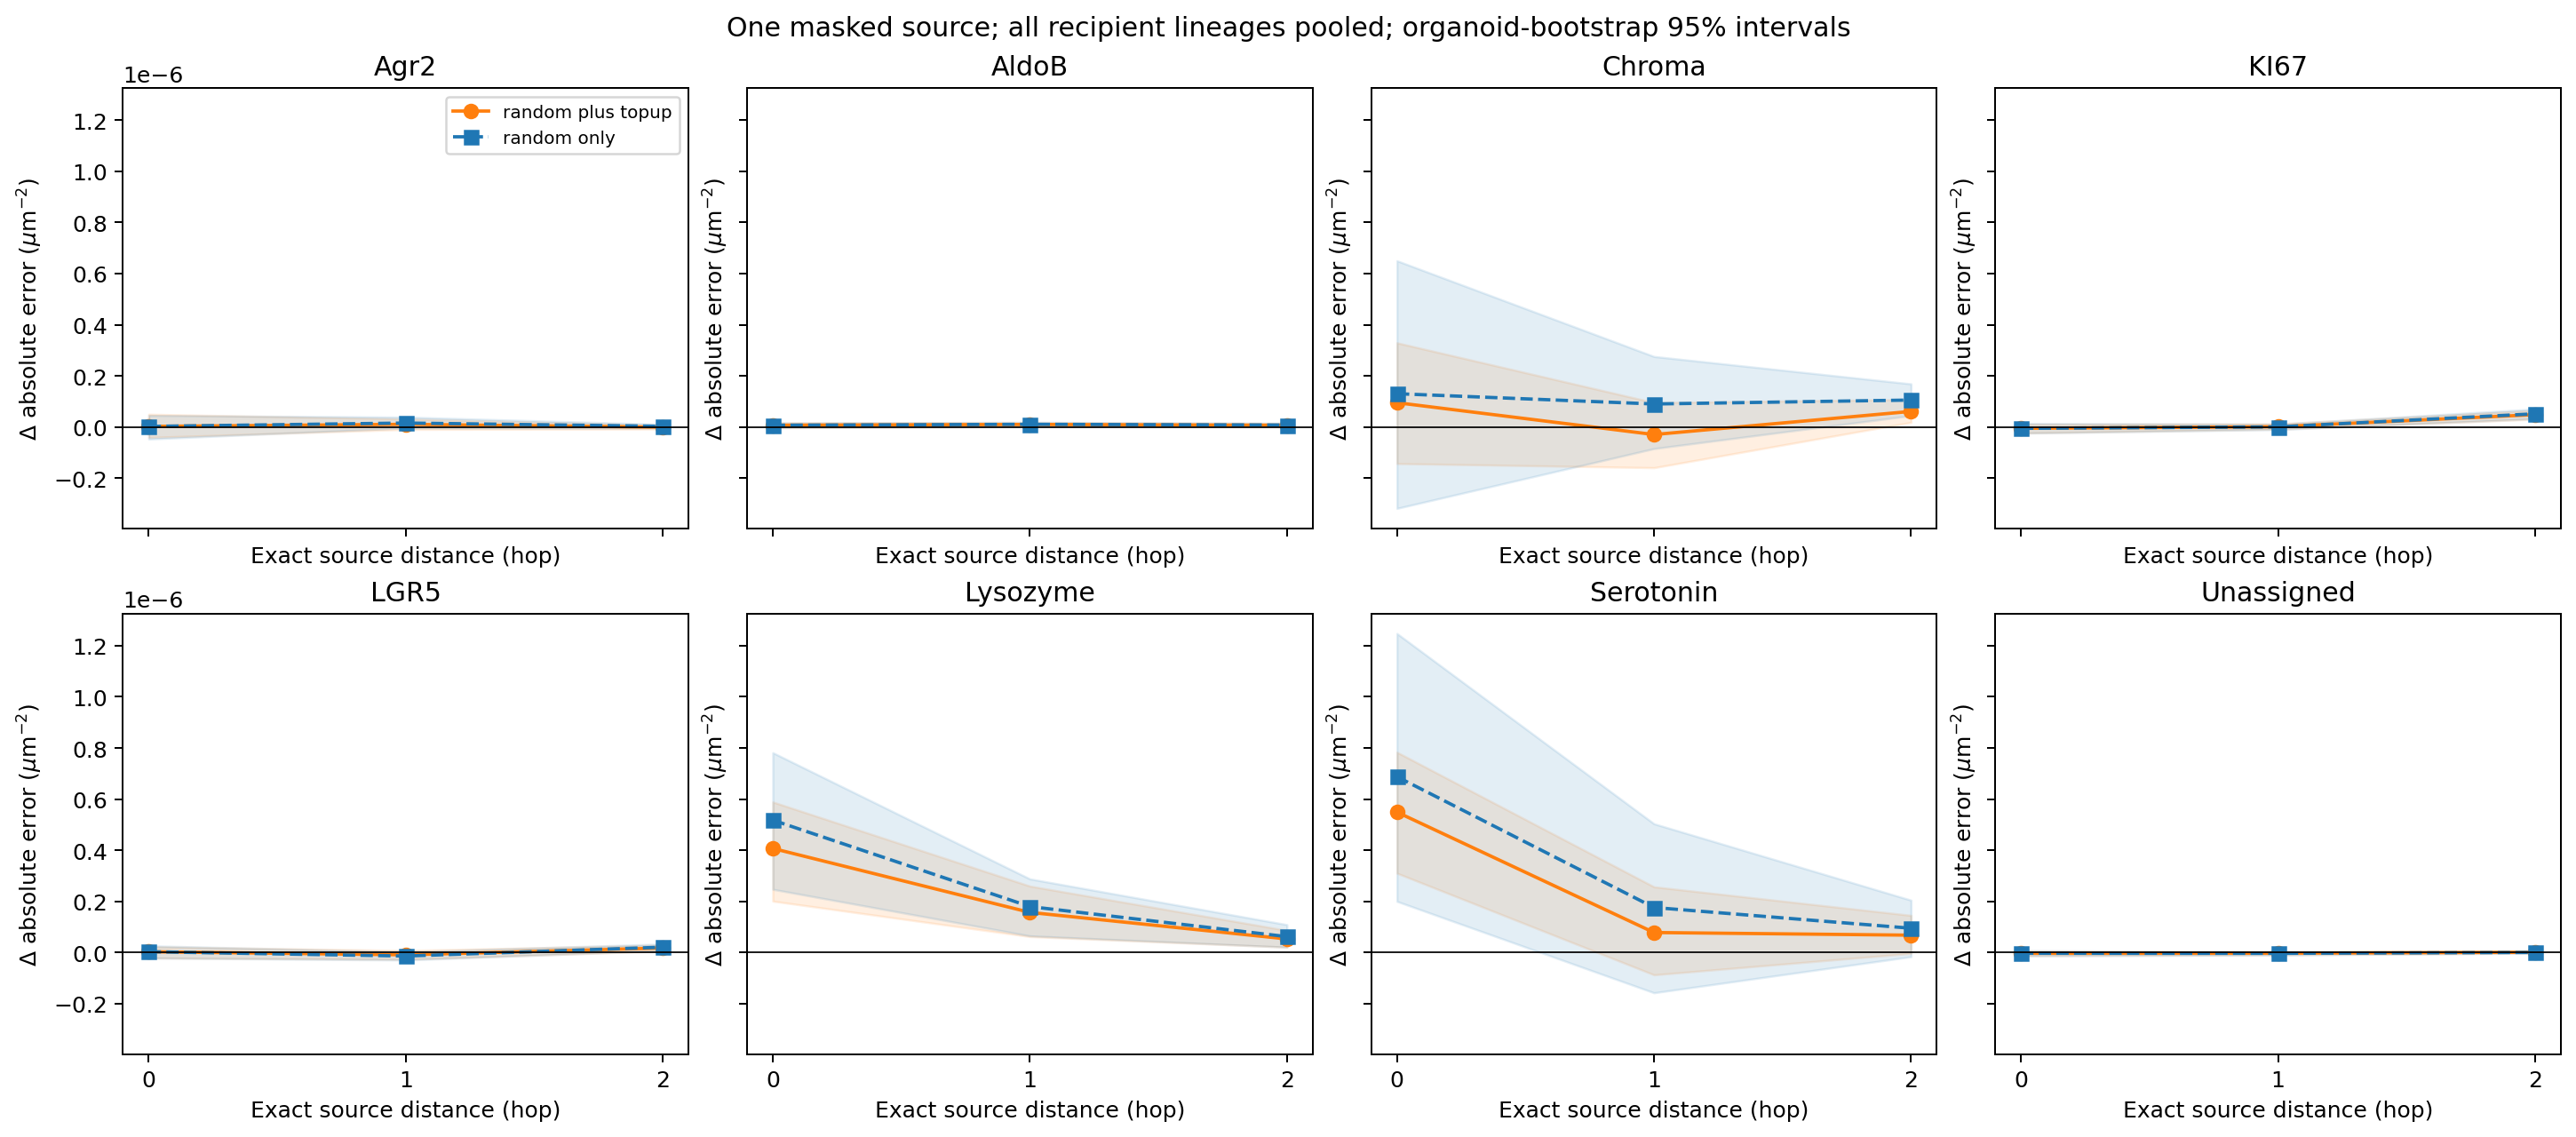

In [7]:
population_cases,population_support=infer_cases('population')
population_support.to_csv(OUTPUT_DIR/'source_hop_sampling_support.csv',index=False)
assert (population_support.selected_count>=np.minimum(population_support.available,MIN_SOURCE_HOP_CASES)).all()
print('Support shortfalls:',int((population_support.shortfall>0).sum()),'source/hop/fold strata.')
fig,axes=plt.subplots(1,3,figsize=(14,4),sharey=True,layout='constrained')
for ax,hop in zip(axes,SOURCE_HOPS):
    g=population_support[population_support.hop==hop].groupby('source_marker_name')[['random_count','selected_count']].sum().reindex(IDENTITIES)
    ax.barh(g.index,g.selected_count,color='tab:orange',label='Random + top-up')
    ax.barh(g.index,g.random_count,color='tab:blue',label='Random')
    ax.set(title=f'Hop {hop}',xlabel='Eligible sampled centers')
axes[0].legend();save_figure(fig,OUTPUT_DIR/'source_hop_support')

# Equal sampled-center weighting within source/hop: average over all recipients.
# Bootstrap whole organoids while retaining their case counts (ratio of totals).
rows=[]
rng=np.random.default_rng(SAMPLING_SEED)
for sample_scope in ['random_plus_topup','random_only']:
    frame=population_cases if sample_scope=='random_plus_topup' else population_cases[population_cases.sample_origin=='random']
    for (source,hop),g in frame.groupby(['source_marker_name','hop']):
        for metric in EFFECT_LABELS:
            units=g.groupby('organoid_str')[metric].agg(['sum','count'])
            weights=rng.multinomial(len(units),np.full(len(units),1/len(units)),size=BOOTSTRAP_REPEATS)
            draws=(weights@units['sum'].to_numpy())/(weights@units['count'].to_numpy())
            low,high=np.quantile(draws,[.025,.975])
            rows.append(dict(sample_scope=sample_scope,source_marker_name=source,hop=hop,metric=metric,
                mean=g[metric].mean(),low=low,high=high,n_cases=len(g),n_organoids=len(units)))
source_summary=pd.DataFrame(rows)
source_summary.to_csv(OUTPUT_DIR/'source_hop_effects.csv',index=False)
for metric,label in EFFECT_LABELS.items():
    fig,axes=plt.subplots(2,4,figsize=(16,7),layout='constrained',sharex=True,sharey=True)
    for ax,name in zip(axes.flat,IDENTITIES):
        for scope,style,color in [('random_plus_topup','o-','tab:orange'),('random_only','s--','tab:blue')]:
            f=source_summary[(source_summary.source_marker_name==name)&(source_summary.metric==metric)&(source_summary.sample_scope==scope)].sort_values('hop')
            ax.plot(f.hop,f['mean'],style,color=color,label=scope.replace('_',' '))
            ax.fill_between(f.hop,f.low,f.high,color=color,alpha=.12)
        ax.axhline(0,color='k',lw=.7);ax.set(title=name,xlabel='Exact source distance (hop)',ylabel=label,xticks=SOURCE_HOPS)
    axes.flat[0].legend(fontsize=8)
    fig.suptitle('One masked source; all recipient lineages pooled; organoid-bootstrap 95% intervals')
    save_figure(fig,OUTPUT_DIR/f'source_hop_{metric}')
(CACHE/'complete.json').write_text(json.dumps(dict(checkpoints=len(records),pair_cases=len(pair_cases),population_cases=len(population_cases))))
